In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('data.csv')

In [4]:
df.head()

,Document,Topic_group,text_length
0,connection with icon icon dear please setup ic...,Hardware,18
1,work experience user work experience user hi w...,Access,19
2,requesting for meeting requesting meeting hi p...,Hardware,14
3,reset passwords for external accounts re expir...,Access,145
4,mail verification warning hi has got attached ...,Miscellaneous,15


In [5]:
df.shape

(47837, 3)

### 1. Feature Selection

Selecting the input feature (Document) and the target variable (Topic_group) for the text classification task.

In [6]:
X = df['Document']
y = df['Topic_group']

### 2. Train-Test Split

Splitting the dataset into training and testing subsets while preserving the class distribution using stratified sampling.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [8]:
print(f'Training Samples: {X_train.shape[0]}')
print(f'Testing Samples: {X_test.shape[0]}')

Training Samples: 38269
Testing Samples: 9568


### 3. Feature Engineering using TF-IDF

Machine learning algorithms cannot understand raw text directly. Therefore, the textual documents are converted into numerical feature vectors using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.

TF-IDF assigns higher importance to informative words while reducing the influence of commonly occurring words across the corpus.

In [9]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [10]:
print(f'Training Samples: {X_train_tfidf.shape[0]}')
print(f'Testing Samples: {X_test_tfidf.shape[0]}')

Training Samples: 38269
Testing Samples: 9568


In [11]:
print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 11659


In [12]:
print(tfidf.vocabulary_)

{'projects': 7865, 'not': 6764, 'open': 6937, 'for': 4196, 'pas': 7238, 'forecast': 4206, 'sent': 9286, 'thursday': 10514, 'hi': 4792, 'could': 2392, 'you': 11627, 'please': 7520, 'investigate': 5462, 'reason': 8193, 'why': 11473, 'forecasting': 4208, 'either': 3355, 'or': 6986, 'thank': 10431, 'budget': 1290, 'dear': 2623, 'be': 932, 'informed': 5223, 'period': 7336, 'version': 11214, 'budgeting': 1293, 'final': 4060, 'mindful': 6376, 'about': 17, 'point': 7539, 'view': 11240, 'should': 9420, 'using': 11114, 'during': 3266, 'cycle': 2555, 'snapshot': 9603, 'below': 991, 'feel': 4000, 'free': 4296, 'circulate': 1726, 'your': 11628, 'teams': 10334, 'necessary': 6645, 'regards': 8418, 'purchase': 7985, 'request': 8673, 'it': 5520, 'owner': 7127, 'id': 4965, 'has': 4705, 'been': 949, 'approved': 547, 'july': 5580, 'pm': 7534, 'allocate': 336, 'backpack': 856, 'log': 5955, 'call': 1415, 'relevant': 8504, 'installation': 5305, 'allocation': 339, 'thanks': 10435, 'note': 6768, 'mailbox': 607

In [13]:
print(list(tfidf.vocabulary_)[:20])

['projects', 'not', 'open', 'for', 'pas', 'forecast', 'sent', 'thursday', 'hi', 'could', 'you', 'please', 'investigate', 'reason', 'why', 'forecasting', 'either', 'or', 'thank', 'budget']


In [14]:
print(X_train.loc[0])
print(X_train_tfidf[0])

connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 44 stored elements and shape (1, 11659)>
  Coords	Values
  (0, 7865)	0.3149745386886278
  (0, 6764)	0.07901374921703593
  (0, 6937)	0.42057788783456457
  (0, 4196)	0.2537523405043323
  (0, 7238)	0.08298829865056125
  (0, 4206)	0.331334821087786
  (0, 9286)	0.09858688836233695
  (0, 10514)	0.10505788437479129
  (0, 4792)	0.03313698087556969
  (0, 2392)	0.064571143287529
  (0, 11627)	0.19449355471837618
  (0, 7520)	0.09481674316571347
  (0, 5462)	0.0839256782220465
  (0, 8193)	0.09420218688016685
  (0, 11473)	0.09340723763610409
  (0, 4208)	0.2572782033439892
  (0, 3355)	0.11319690709120811
  (0, 6986)	0.07250392850235418
  (0, 10431)	0.07036204070130819
  (0, 1290)	0.1255626640668965
  (0, 2623)	0.04797214246690877
  (0, 932)	0.1860175016464141
  (0, 5223)	0.08787792822664595
  (0, 7336)	0.08511408025281308
  (0, 11

### 4. Model Training - Logistic Regression (Baseline)

After converting the text into TF-IDF feature vectors, the first baseline model is trained using Logistic Regression.

Logistic Regression is widely used for text classification because it performs well on high-dimensional sparse datasets and serves as an excellent baseline model.

In [15]:
model = LogisticRegression(random_state = 42, max_iter = 1000)
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [16]:
y_pred = model.predict(X_test_tfidf)
y_pred

array(['Internal Project', 'HR Support', 'Miscellaneous', ...,
       'HR Support', 'Hardware', 'Storage'], shape=(9568,), dtype=object)

### 5. Model Evaluation

The trained Logistic Regression model is evaluated using multiple performance metrics.

Instead of relying only on accuracy, additional metrics such as Precision, Recall, F1-Score and Confusion Matrix are used to obtain a comprehensive understanding of the model's performance.

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8582


In [18]:
print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1425
Administrative rights       0.90      0.66      0.76       352
           HR Support       0.86      0.86      0.86      2183
             Hardware       0.80      0.90      0.84      2724
     Internal Project       0.92      0.81      0.86       424
        Miscellaneous       0.84      0.83      0.83      1412
             Purchase       0.98      0.87      0.92       493
              Storage       0.95      0.85      0.90       555

             accuracy                           0.86      9568
            macro avg       0.89      0.83      0.86      9568
         weighted avg       0.86      0.86      0.86      9568



In [19]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1246    3   37   97    3   35    0    4]
 [   6  231    9   93    1   10    2    0]
 [  28    3 1882  192    9   61    1    7]
 [  54   14  123 2438    6   79    5    5]
 [   3    0   29   30  344   18    0    0]
 [  20    2   78  128    8 1167    1    8]
 [   2    3    7   40    1    9  429    2]
 [   2    2   24   41    0   12    0  474]]


<Figure size 1000x800 with 0 Axes>

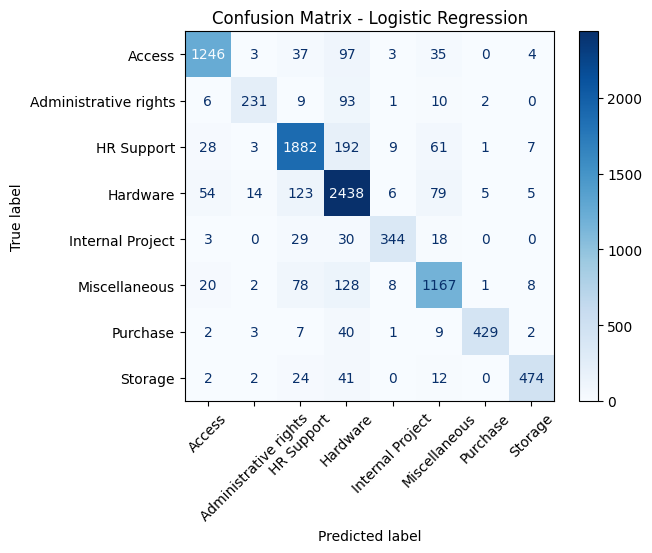

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

plt.figure(figsize=(10,8))

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [21]:
results = pd.DataFrame({
    "Document": X_test,
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Document,Actual,Predicted
12352,project codes july pm codes hello please assig...,Internal Project,Internal Project
33948,new starter pop ad july re date merci ale ext ...,HR Support,HR Support
21267,add to thursday february re update thanks plea...,Miscellaneous,Miscellaneous
17680,create record net which points to thursday pm ...,Access,Access
20205,all buyers mail february pm buyers hello pleas...,Miscellaneous,Miscellaneous


In [22]:
results.shape

(9568, 3)

In [24]:
results.to_csv('baselineResults.csv', index = False)